# Binomial Theorem

## Contents
1. [Prerequisites: Factorials and Combinations](#1.-Prerequisites:-Factorials-and-Combinations)
2. [Pascal's Triangle](#2.-Pascal's-Triangle)
3. [The Binomial Theorem](#3.-The-Binomial-Theorem)
4. [Expanding Binomials](#4.-Expanding-Binomials)
5. [General Term](#5.-General-Term)
6. [Specific Terms: Coefficient of x^k and Term Independent of x](#6.-Specific-Terms:-Coefficient-of-x^k-and-Term-Independent-of-x)
7. [Middle Terms](#7.-Middle-Terms)
8. [Greatest Coefficient and Numerically Greatest Term](#8.-Greatest-Coefficient-and-Numerically-Greatest-Term)
9. [Properties of Binomial Coefficients](#9.-Properties-of-Binomial-Coefficients)
10. [Applications: Approximation, Divisibility, Remainders](#10.-Applications:-Approximation,-Divisibility,-Remainders)
11. [Binomial Theorem for Any Index](#11.-Binomial-Theorem-for-Any-Index)
12. [Multinomial Theorem](#12.-Multinomial-Theorem)
13. [Link to Probability](#13.-Link-to-Probability)
14. [Common Mistakes](#14.-Common-Mistakes)
15. [Formula Sheet](#15.-Formula-Sheet)
16. [Practice Problems (with Answers)](#16.-Practice-Problems-(with-Answers))

**Notation:** $\binom{n}{r}$, ${}^nC_r$ and $C(n, r)$ all mean "$n$ choose $r$". The code cells use SymPy, NumPy and Matplotlib.

In [1]:
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from math import comb, factorial

x, y, a, b, c, n, r = sp.symbols("x y a b c n r")

def general_term(first, second, power, r):
    """T_{r+1} = C(power, r) * first^(power - r) * second^r"""
    return sp.binomial(power, r) * first**(power - r) * second**r

print("Ready.")

Ready.


## 1. Prerequisites: Factorials and Combinations

### Factorial
$$n! = n(n - 1)(n - 2)\cdots 2 \cdot 1, \qquad 0! = 1$$
$5! = 120$, $\;n! = n \cdot (n - 1)!$

### Combinations
The number of ways to choose $r$ objects from $n$ (order does not matter):
$$\boxed{\binom{n}{r} = \frac{n!}{r!\,(n - r)!}}, \qquad 0 \le r \le n$$

$\binom{8}{3} = \dfrac{8 \cdot 7 \cdot 6}{3 \cdot 2 \cdot 1} = 56$. **Shortcut:** multiply $r$ numbers counting down from $n$, divide by $r!$.

### Key properties
| Property | Rule |
|----------|------|
| Ends | $\binom{n}{0} = \binom{n}{n} = 1$, $\;\binom{n}{1} = n$ |
| Symmetry | $\binom{n}{r} = \binom{n}{n - r}$ (so $\binom{10}{7} = \binom{10}{3} = 120$) |
| **Pascal's rule** | $\binom{n}{r} + \binom{n}{r - 1} = \binom{n + 1}{r}$ |
| Absorption | $\binom{n}{r} = \dfrac{n}{r}\binom{n - 1}{r - 1}$ |
| Ratio of neighbours | $\dfrac{\binom{n}{r}}{\binom{n}{r - 1}} = \dfrac{n - r + 1}{r}$ |
| Equal coefficients | $\binom{n}{p} = \binom{n}{q} \Rightarrow p = q$ or $p + q = n$ |

In [2]:
print("5! =", factorial(5), "| C(8,3) =", comb(8, 3), "| C(10,7) =", comb(10, 7), "= C(10,3) =", comb(10, 3))
print("Pascal's rule check (n=9, r=4):", comb(9, 4) + comb(9, 3), "=", comb(10, 4))
print("Absorption check (n=9, r=4):", comb(9, 4), "=", sp.Rational(9, 4) * comb(8, 3))

5! = 120 | C(8,3) = 56 | C(10,7) = 120 = C(10,3) = 120
Pascal's rule check (n=9, r=4): 210 = 210
Absorption check (n=9, r=4): 126 = 126


## 2. Pascal's Triangle

Each entry is the sum of the two entries above it (Pascal's rule). Row $n$ (starting from row 0) lists $\binom{n}{0}, \binom{n}{1}, \dots, \binom{n}{n}$ — the coefficients of $(a + b)^n$.

```
n = 0                    1
n = 1                  1   1
n = 2                1   2   1
n = 3              1   3   3   1
n = 4            1   4   6   4   1
n = 5          1   5  10  10   5   1
n = 6        1   6  15  20  15   6   1
n = 7      1   7  21  35  35  21   7   1
```

### Patterns
- Each row is **symmetric**.
- The sum of row $n$ is $2^n$.
- The second diagonal is the natural numbers; the third is the triangular numbers $1, 3, 6, 10, \dots$
- Row $n$ read as digits gives $11^n$ for small $n$ ($11^2 = 121$, $11^4 = 14641$).
- Colouring the odd entries produces the **Sierpinski triangle** (see the plot below).

                    1                   
                  1   1                 
                1   2   1               
              1   3   3   1             
            1   4   6   4   1           
          1   5  10  10   5   1         
        1   6  15  20  15   6   1       
      1   7  21  35  35  21   7   1     

Row sums: [1, 2, 4, 8, 16, 32, 64, 128]
11^n: [1, 11, 121, 1331, 14641]


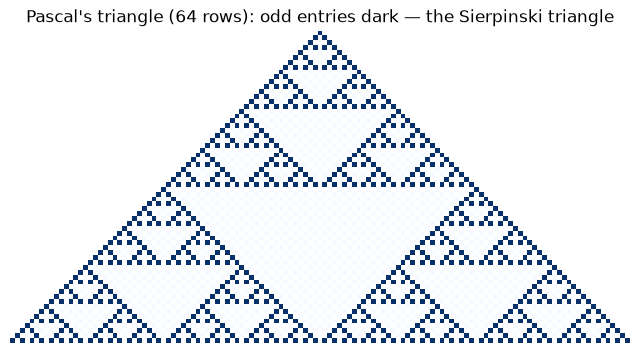

In [3]:
for row in range(8):
    print(" ".join(f"{comb(row, k):>3}" for k in range(row + 1)).center(40))
print("\nRow sums:", [sum(comb(row, k) for k in range(row + 1)) for row in range(8)])
print("11^n:", [11**i for i in range(5)])

N = 64
grid = np.zeros((N, 2*N - 1))
for row in range(N):
    for k in range(row + 1):
        grid[row, N - 1 - row + 2*k] = comb(row, k) % 2 + 0.15   # odd entries bright, even entries faint
plt.figure(figsize=(8, 4.5))
plt.imshow(np.where(grid > 0, grid, np.nan), cmap="Blues", interpolation="nearest")
plt.axis("off"); plt.title("Pascal's triangle (64 rows): odd entries dark — the Sierpinski triangle")
plt.show()

## 3. The Binomial Theorem

For any positive integer $n$:
$$\boxed{(a + b)^n = \sum_{r=0}^{n}\binom{n}{r}a^{n-r}b^{r} = \binom{n}{0}a^n + \binom{n}{1}a^{n-1}b + \binom{n}{2}a^{n-2}b^2 + \dots + \binom{n}{n}b^n}$$

### Why it works (counting argument)
$(a + b)^n = (a + b)(a + b)\cdots(a + b)$ — $n$ brackets. Each term of the product picks $a$ or $b$ from each bracket. To get $a^{n-r}b^r$ you choose **which $r$ brackets** give $b$: that can be done in $\binom{n}{r}$ ways.

### Proof by induction (sketch)
True for $n = 1$. If true for $n$, multiply by $(a + b)$; the coefficient of $a^{n+1-r}b^r$ becomes $\binom{n}{r} + \binom{n}{r - 1} = \binom{n + 1}{r}$ by Pascal's rule. ∎

### Observations
- There are $n + 1$ terms.
- Powers of $a$ go **down** from $n$ to 0; powers of $b$ go **up** from 0 to $n$; in each term they **add to $n$**.
- Coefficients are symmetric: $\binom{n}{r} = \binom{n}{n - r}$.

### Important special forms
| Expansion | Result |
|-----------|--------|
| $(a - b)^n$ | $\sum (-1)^r\binom{n}{r}a^{n-r}b^r$ — signs **alternate** |
| $(1 + x)^n$ | $\binom{n}{0} + \binom{n}{1}x + \binom{n}{2}x^2 + \dots + \binom{n}{n}x^n$ |
| $(1 - x)^n$ | $\binom{n}{0} - \binom{n}{1}x + \binom{n}{2}x^2 - \dots + (-1)^n\binom{n}{n}x^n$ |
| $(a + b)^n + (a - b)^n$ | $2[\text{terms with } r \text{ even}]$ — odd terms cancel |
| $(a + b)^n - (a - b)^n$ | $2[\text{terms with } r \text{ odd}]$ — even terms cancel |

## 4. Expanding Binomials

**Example 1.** $(x + y)^4 = x^4 + 4x^3y + 6x^2y^2 + 4xy^3 + y^4$ (coefficients from row 4: $1, 4, 6, 4, 1$).

**Example 2.** $(2x - 3)^4$. Take $a = 2x$, $b = -3$:
$$= (2x)^4 + 4(2x)^3(-3) + 6(2x)^2(-3)^2 + 4(2x)(-3)^3 + (-3)^4$$
$$= 16x^4 - 96x^3 + 216x^2 - 216x + 81$$

**Example 3.** $\left(x + \dfrac{1}{x}\right)^4 = x^4 + 4x^2 + 6 + \dfrac{4}{x^2} + \dfrac{1}{x^4}$

**Example 4 (irrational terms).** $(\sqrt{2} + 1)^4 + (\sqrt{2} - 1)^4 = 2\left[(\sqrt{2})^4 + 6(\sqrt{2})^2 + 1\right] = 2(4 + 12 + 1) = 34$.
The odd-$r$ terms cancel, so the result is an integer.

**Tip:** Put brackets around each part and substitute carefully — sign and power errors on $b$ are the most common mistake.

In [4]:
for expr in [(x + y)**4, (2*x - 3)**4, (x + 1/x)**4, (1 - 2*x)**5]:
    print(f"{str(expr):<14} = {sp.expand(expr)}")
print("(√2+1)^4 + (√2-1)^4 =", sp.expand((sp.sqrt(2) + 1)**4 + (sp.sqrt(2) - 1)**4))

(x + y)**4     = x**4 + 4*x**3*y + 6*x**2*y**2 + 4*x*y**3 + y**4
(2*x - 3)**4   = 16*x**4 - 96*x**3 + 216*x**2 - 216*x + 81
(x + 1/x)**4   = x**4 + 4*x**2 + 6 + 4/x**2 + x**(-4)
(1 - 2*x)**5   = -32*x**5 + 80*x**4 - 80*x**3 + 40*x**2 - 10*x + 1
(√2+1)^4 + (√2-1)^4 = 34


## 5. General Term

The $(r + 1)$-th term of $(a + b)^n$ is
$$\boxed{T_{r+1} = \binom{n}{r}a^{n-r}b^{r}}, \qquad r = 0, 1, \dots, n$$

**Note the off-by-one:** the 4th term has $r = 3$.

For $(a - b)^n$: $\;T_{r+1} = (-1)^r\binom{n}{r}a^{n-r}b^r$.

The $r$-th term **from the end** of $(a + b)^n$ is the $(n - r + 2)$-th term from the start, or equivalently the $r$-th term of $(b + a)^n$.

**Example.** 4th term of $(x - 2y)^7$: $r = 3$,
$$T_4 = \binom{7}{3}x^4(-2y)^3 = 35 \cdot (-8)\,x^4y^3 = -280\,x^4y^3$$

**Example.** 5th term of $\left(2x - \dfrac{1}{x}\right)^8$: $r = 4$,
$$T_5 = \binom{8}{4}(2x)^4\left(-\frac{1}{x}\right)^4 = 70 \cdot 16 = 1120$$

In [5]:
print("4th term of (x - 2y)^7:", general_term(x, -2*y, 7, 3))
print("5th term of (2x - 1/x)^8:", sp.simplify(general_term(2*x, -1/x, 8, 4)))

4th term of (x - 2y)^7: -280*x**4*y**3
5th term of (2x - 1/x)^8: 1120


## 6. Specific Terms: Coefficient of $x^k$ and Term Independent of $x$

### Method
1. Write the general term $T_{r+1}$ and simplify the **power of $x$** as a function of $r$.
2. Set the power equal to $k$ (or to $0$ for the term independent of $x$) and solve for $r$.
3. $r$ must be an **integer** with $0 \le r \le n$. If not, no such term exists (coefficient $= 0$).
4. Substitute $r$ back.

**Example (coefficient).** Coefficient of $x^5$ in $(x + 3)^8$:
$T_{r+1} = \binom{8}{r}x^{8-r}3^r$. Need $8 - r = 5 \Rightarrow r = 3$ → $\binom{8}{3} \cdot 27 = 56 \cdot 27 = 1512$.

**Example (constant term).** Term independent of $x$ in $\left(x^2 + \dfrac{1}{x}\right)^9$:
$T_{r+1} = \binom{9}{r}x^{2(9 - r)}x^{-r} = \binom{9}{r}x^{18 - 3r}$. Need $18 - 3r = 0 \Rightarrow r = 6$ → $\binom{9}{6} = 84$.

**Example (classic).** Term independent of $x$ in $\left(\dfrac{3x^2}{2} - \dfrac{1}{3x}\right)^9$:
$T_{r+1} = \binom{9}{r}\left(\tfrac{3}{2}\right)^{9-r}\left(-\tfrac{1}{3}\right)^r x^{18 - 3r}$. $r = 6$:
$$\binom{9}{6}\left(\tfrac{3}{2}\right)^3\left(\tfrac{1}{3}\right)^6 = 84 \cdot \frac{27}{8} \cdot \frac{1}{729} = \frac{7}{18}$$

**Example (no such term).** Is there an $x^4$ term in $\left(x + \dfrac{1}{x}\right)^7$? Power is $7 - 2r = 4 \Rightarrow r = 1.5$ — not an integer, so **no**.

**Example (product of two expansions).** Coefficient of $x^2$ in $(1 + x)(1 - 2x)^5$:
$= [\text{coeff of } x^2 \text{ in } (1 - 2x)^5] + [\text{coeff of } x^1] = \binom{5}{2}4 + \binom{5}{1}(-2) = 40 - 10 = 30$.

In [6]:
def coeff(expr, power):
    return sp.expand(expr).coeff(x, power) if power != 0 else sp.expand(expr).as_independent(x)[0]

print("coeff of x^5 in (x+3)^8          :", coeff((x + 3)**8, 5))
print("constant in (x^2 + 1/x)^9        :", coeff((x**2 + 1/x)**9, 0))
print("constant in (3x^2/2 - 1/(3x))^9  :", coeff((sp.Rational(3, 2)*x**2 - 1/(3*x))**9, 0))
print("coeff of x^4 in (x + 1/x)^7      :", coeff((x + 1/x)**7, 4))
print("coeff of x^2 in (1+x)(1-2x)^5    :", coeff((1 + x)*(1 - 2*x)**5, 2))

coeff of x^5 in (x+3)^8          : 1512
constant in (x^2 + 1/x)^9        : 84
constant in (3x^2/2 - 1/(3x))^9  : 7/18
coeff of x^4 in (x + 1/x)^7      : 0
coeff of x^2 in (1+x)(1-2x)^5    : 30


## 7. Middle Terms

| $n$ | Number of terms | Middle term(s) |
|-----|-----------------|----------------|
| Even | $n + 1$ (odd) | One: $T_{\frac{n}{2} + 1}$ |
| Odd | $n + 1$ (even) | Two: $T_{\frac{n+1}{2}}$ and $T_{\frac{n+3}{2}}$ |

**Example (even).** Middle term of $(x + 2)^8$: $T_5 = \binom{8}{4}x^4 2^4 = 70 \cdot 16\,x^4 = 1120x^4$.

**Example (odd).** Middle terms of $\left(3x - \dfrac{x^3}{6}\right)^7$: $T_4$ and $T_5$.
$$T_4 = \binom{7}{3}(3x)^4\left(-\frac{x^3}{6}\right)^3 = -\frac{105}{8}x^{13}, \qquad T_5 = \binom{7}{4}(3x)^3\left(-\frac{x^3}{6}\right)^4 = \frac{35}{48}x^{15}$$

The middle term has the **largest binomial coefficient** (Section 8).

In [7]:
print("Middle of (x+2)^8:", general_term(x, 2, 8, 4))
print("Middle of (3x - x^3/6)^7:", sp.simplify(general_term(3*x, -x**3/6, 7, 3)), "and", sp.simplify(general_term(3*x, -x**3/6, 7, 4)))

Middle of (x+2)^8: 1120*x**4
Middle of (3x - x^3/6)^7: -105*x**13/8 and 35*x**15/48


## 8. Greatest Coefficient and Numerically Greatest Term

### Greatest binomial coefficient
The coefficients $\binom{n}{r}$ increase up to the middle and then decrease.
- $n$ even: greatest is $\binom{n}{n/2}$
- $n$ odd: greatest are $\binom{n}{\frac{n-1}{2}} = \binom{n}{\frac{n+1}{2}}$ (two equal)

### Numerically greatest term of $(1 + x)^n$
(Here the *term* includes the value of $x$, not just the binomial coefficient.) Compare consecutive terms:
$$\left|\frac{T_{r+1}}{T_r}\right| = \frac{n - r + 1}{r}\,|x|$$
Terms keep growing while this ratio is $\ge 1$. Solving gives
$$r \le \frac{(n + 1)|x|}{1 + |x|}$$
Let $m = \dfrac{(n + 1)|x|}{1 + |x|}$.
- If $m$ is an integer, $T_m$ and $T_{m+1}$ are **equal and greatest**.
- Otherwise the greatest term is $T_{\lfloor m\rfloor + 1}$.

For $(a + b)^n$, factor out first: $(a + b)^n = a^n\left(1 + \tfrac{b}{a}\right)^n$.

**Example.** Numerically greatest term of $(2 + 3x)^9$ at $x = \tfrac{3}{2}$:
$(2 + 3x)^9 = 2^9\left(1 + \tfrac{3x}{2}\right)^9$, and $\tfrac{3x}{2} = \tfrac{9}{4}$.
$m = \dfrac{10 \cdot 9/4}{1 + 9/4} = \dfrac{90}{13} \approx 6.92$ → greatest term is $T_7$:
$$T_7 = \binom{9}{6}2^3\left(\tfrac{9}{2}\right)^6 = \frac{7 \cdot 3^{13}}{2}$$

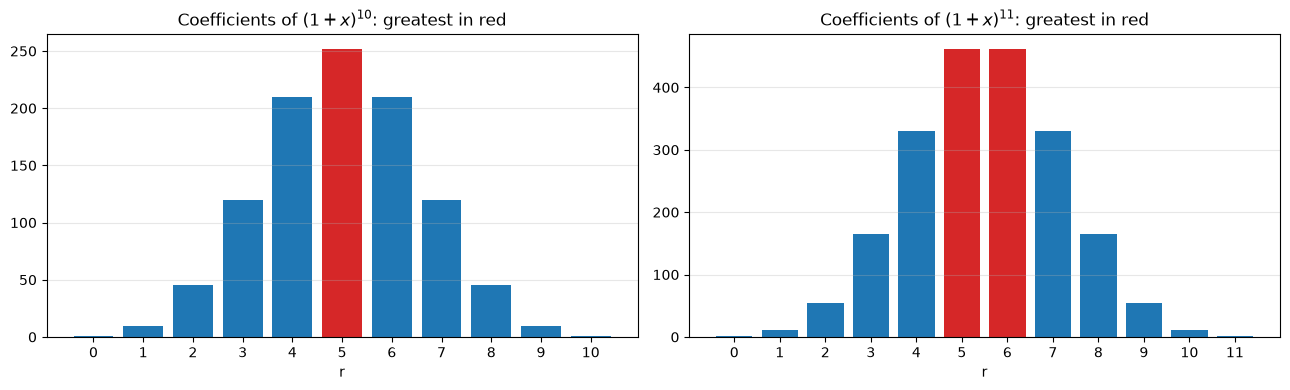

Terms: [512.0, 10368.0, 93312.0, 489888.0, 1653372.0, 3720087.0, 5580130.5, 5380840.125, 3026722.5703125, 756680.642578125]
Greatest is T_7 = 11160261/2   (7·3^13/2 = 11160261/2 )


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, N in zip(axes, (10, 11)):
    coeffs = [comb(N, k) for k in range(N + 1)]
    bars = ax.bar(range(N + 1), coeffs, color=["C3" if v == max(coeffs) else "C0" for v in coeffs])
    ax.set_title(f"Coefficients of $(1+x)^{{{N}}}$: greatest in red"); ax.set_xlabel("r"); ax.set_xticks(range(N + 1))
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# Numerically greatest term of (2 + 3x)^9 at x = 3/2
xv = sp.Rational(3, 2)
terms = [general_term(2, 3*xv, 9, k) for k in range(10)]
best = max(range(10), key=lambda k: abs(terms[k]))
print("Terms:", [float(t) for t in terms])
print(f"Greatest is T_{best + 1} =", terms[best], "  (7·3^13/2 =", sp.Rational(7 * 3**13, 2), ")")

## 9. Properties of Binomial Coefficients

Write $C_r = \binom{n}{r}$. Most results come from **substituting a value** of $x$ in
$$(1 + x)^n = C_0 + C_1x + C_2x^2 + \dots + C_nx^n$$
or from **differentiating** it.

| Result | How |
|--------|-----|
| $C_0 + C_1 + C_2 + \dots + C_n = 2^n$ | put $x = 1$ |
| $C_0 - C_1 + C_2 - \dots + (-1)^nC_n = 0$ | put $x = -1$ |
| $C_0 + C_2 + C_4 + \dots = C_1 + C_3 + C_5 + \dots = 2^{n-1}$ | add / subtract the two above |
| $C_1 + 2C_2 + 3C_3 + \dots + nC_n = n\,2^{n-1}$ | differentiate, put $x = 1$ (or use $rC_r = nC^{n-1}_{r-1}$) |
| $C_0^2 + C_1^2 + \dots + C_n^2 = \binom{2n}{n}$ | coefficient of $x^n$ in $(1 + x)^n(1 + x)^n$ |
| $\sum_{k}\binom{m}{k}\binom{n}{r - k} = \binom{m + n}{r}$ | **Vandermonde's identity** |
| $C_0 + \dfrac{C_1}{2} + \dfrac{C_2}{3} + \dots + \dfrac{C_n}{n + 1} = \dfrac{2^{n+1} - 1}{n + 1}$ | integrate from 0 to 1 |

**Example.** For $n = 10$: sum $= 1024$, even-position sum $= 512$, $\sum rC_r = 10 \cdot 512 = 5120$, $\sum C_r^2 = \binom{20}{10} = 184756$.

**Combinatorial meaning of $\sum C_r = 2^n$:** both sides count all subsets of an $n$-element set.

In [9]:
for N in (5, 10):
    C = [comb(N, k) for k in range(N + 1)]
    print(f"n = {N}:  ΣC = {sum(C)} (2^n = {2**N}),  Σ(-1)^r C = {sum((-1)**k * v for k, v in enumerate(C))},"
          f"  even = {sum(C[0::2])}, odd = {sum(C[1::2])},  Σ rC = {sum(k*v for k, v in enumerate(C))} (n·2^(n-1) = {N * 2**(N - 1)}),"
          f"  ΣC² = {sum(v*v for v in C)} (C(2n,n) = {comb(2*N, N)}),  ΣC/(r+1) = {sum(sp.Rational(v, k + 1) for k, v in enumerate(C))} (= {sp.Rational(2**(N + 1) - 1, N + 1)})")
print("Vandermonde (m=4, n=6, r=5):", sum(comb(4, k) * comb(6, 5 - k) for k in range(6)), "=", comb(10, 5))
nn = sp.symbols("n", integer=True, nonnegative=True)
print("Symbolic: Σ C(n,r) =", sp.simplify(sp.summation(sp.binomial(nn, r), (r, 0, nn))))

n = 5:  ΣC = 32 (2^n = 32),  Σ(-1)^r C = 0,  even = 16, odd = 16,  Σ rC = 80 (n·2^(n-1) = 80),  ΣC² = 252 (C(2n,n) = 252),  ΣC/(r+1) = 21/2 (= 21/2)
n = 10:  ΣC = 1024 (2^n = 1024),  Σ(-1)^r C = 0,  even = 512, odd = 512,  Σ rC = 5120 (n·2^(n-1) = 5120),  ΣC² = 184756 (C(2n,n) = 184756),  ΣC/(r+1) = 2047/11 (= 2047/11)
Vandermonde (m=4, n=6, r=5): 252 = 252
Symbolic: Σ C(n,r) = 2**n


## 10. Applications: Approximation, Divisibility, Remainders

### Approximations
When $x$ is small, the terms shrink quickly, so a few terms are enough.

**Example.** $(1.02)^{10} = (1 + 0.02)^{10} \approx 1 + 10(0.02) + 45(0.02)^2 + 120(0.02)^3 = 1 + 0.2 + 0.018 + 0.00096 = 1.21896$ (actual $1.218994\ldots$).

**Example.** $(0.99)^5 = (1 - 0.01)^5 \approx 1 - 0.05 + 0.001 - 0.00001 = 0.95099$.

### Comparing large numbers
**Example.** Which is larger, $(1.1)^{10000}$ or $1000$?
$(1 + 0.1)^{10000} > 1 + 10000(0.1) = 1001 > 1000$. (All the other terms are positive.)

**Example.** Which is larger, $101^{50}$ or $99^{50} + 100^{50}$?
$101^{50} - 99^{50} = (100 + 1)^{50} - (100 - 1)^{50} = 2\left[\binom{50}{1}100^{49} + \binom{50}{3}100^{47} + \dots\right] > 2 \cdot 50 \cdot 100^{49} = 100^{50}$.
So $101^{50} > 99^{50} + 100^{50}$.

### Divisibility
Write the base as (multiple of $d$) $\pm 1$ and expand.

**Example.** Show $9^n - 8n - 1$ is divisible by 64:
$9^n = (1 + 8)^n = 1 + 8n + \binom{n}{2}8^2 + \binom{n}{3}8^3 + \dots$, so $9^n - 8n - 1 = 64\left[\binom{n}{2} + \binom{n}{3}8 + \dots\right]$. ∎

### Remainders
**Example.** Remainder when $2^{100}$ is divided by 7:
$2^{100} = 2 \cdot 2^{99} = 2 \cdot 8^{33} = 2(7 + 1)^{33} = 2(7k + 1) = 14k + 2$ → remainder **2**.

**Example.** Last two digits of $3^{20}$:
$3^{20} = 9^{10} = (10 - 1)^{10} = 10^{10} - \dots + \binom{10}{2}10^2 - \binom{10}{1}10 + 1$. Every term except the last two is a multiple of 100, and $-100 + 1 \equiv 1 \pmod{100}$ → last two digits **01**.

In [10]:
approx = sum(comb(10, k) * 0.02**k for k in range(4))
print(f"(1.02)^10 ≈ {approx:.5f}   actual {1.02**10:.6f}")
approx = sum(comb(5, k) * (-0.01)**k for k in range(4))
print(f"(0.99)^5  ≈ {approx:.5f}   actual {0.99**5:.8f}")
print("1.1^10000 > 1000:", 10000 * math.log10(1.1) > 3, f"(1.1^10000 ≈ 10^{10000 * math.log10(1.1):.0f})")
print("101^50 > 99^50 + 100^50:", 101**50 > 99**50 + 100**50)
print("9^n - 8n - 1 divisible by 64 for n = 1..15:", all((9**k - 8*k - 1) % 64 == 0 for k in range(1, 16)))
print("2^100 mod 7 =", pow(2, 100, 7), "| last two digits of 3^20:", str(3**20)[-2:], f"(3^20 = {3**20})")

(1.02)^10 ≈ 1.21896   actual 1.218994
(0.99)^5  ≈ 0.95099   actual 0.95099005
1.1^10000 > 1000: True (1.1^10000 ≈ 10^414)
101^50 > 99^50 + 100^50: True
9^n - 8n - 1 divisible by 64 for n = 1..15: True
2^100 mod 7 = 2 | last two digits of 3^20: 01 (3^20 = 3486784401)


## 11. Binomial Theorem for Any Index

For **any real** $n$ (negative or fractional) and $|x| < 1$:
$$\boxed{(1 + x)^n = 1 + nx + \frac{n(n - 1)}{2!}x^2 + \frac{n(n - 1)(n - 2)}{3!}x^3 + \dots}$$

- The series is **infinite** (unless $n$ is a non-negative integer, when it stops).
- It is valid **only when $|x| < 1$**.
- The first term must be **1**: for $(a + b)^n$ write $a^n\left(1 + \tfrac{b}{a}\right)^n$, valid when $\left|\tfrac{b}{a}\right| < 1$.
- General term: $\;T_{r+1} = \dfrac{n(n - 1)\cdots(n - r + 1)}{r!}x^r$.

### Standard expansions ($|x| < 1$)
| Expression | Expansion | Coefficient of $x^r$ |
|------------|-----------|----------------------|
| $(1 - x)^{-1}$ | $1 + x + x^2 + x^3 + \dots$ | $1$ |
| $(1 + x)^{-1}$ | $1 - x + x^2 - x^3 + \dots$ | $(-1)^r$ |
| $(1 - x)^{-2}$ | $1 + 2x + 3x^2 + 4x^3 + \dots$ | $r + 1$ |
| $(1 + x)^{-2}$ | $1 - 2x + 3x^2 - 4x^3 + \dots$ | $(-1)^r(r + 1)$ |
| $(1 - x)^{-n}$ | $\sum \binom{n + r - 1}{r}x^r$ | $\binom{n + r - 1}{r}$ |
| $(1 + x)^{1/2}$ | $1 + \tfrac{1}{2}x - \tfrac{1}{8}x^2 + \tfrac{1}{16}x^3 - \dots$ | |
| $(1 + x)^{-1/2}$ | $1 - \tfrac{1}{2}x + \tfrac{3}{8}x^2 - \tfrac{5}{16}x^3 + \dots$ | |

### Approximating roots
- $\sqrt{1.02} = (1 + 0.02)^{1/2} \approx 1 + 0.01 - 0.00005 = 1.00995$
- $\sqrt{99} = 10(1 - 0.01)^{1/2} \approx 10(1 - 0.005 - 0.0000125) = 9.949875$
- $\sqrt[3]{1001} = 10(1 + 0.001)^{1/3} \approx 10(1 + 0.000333) = 10.00333$

**First-order rule:** for small $x$, $(1 + x)^n \approx 1 + nx$.

1/(1 - x)      = 1 + x + x**2 + x**3 + O(x**4)
1/(x + 1)      = 1 - x + x**2 - x**3 + O(x**4)
(1 - x)**(-2)  = 1 + 2*x + 3*x**2 + 4*x**3 + O(x**4)
sqrt(x + 1)    = 1 + x/2 - x**2/8 + x**3/16 + O(x**4)
1/sqrt(x + 1)  = 1 - x/2 + 3*x**2/8 - 5*x**3/16 + O(x**4)

√1.02  ≈ 1.009950   actual 1.009950494
√99    ≈ 9.949875   actual 9.94987437
∛1001  ≈ 10.00333   actual 10.003332


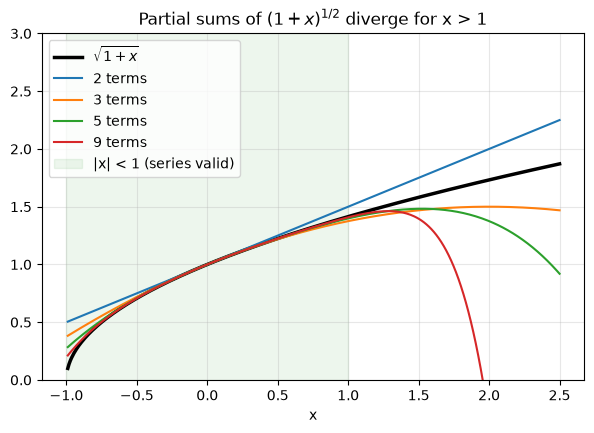

In [11]:
for expr in [(1 - x)**-1, (1 + x)**-1, (1 - x)**-2, (1 + x)**sp.Rational(1, 2), (1 + x)**sp.Rational(-1, 2)]:
    print(f"{str(expr):<14} = {sp.series(expr, x, 0, 4)}")
print(f"\n√1.02  ≈ {1 + 0.01 - 0.00005:.6f}   actual {math.sqrt(1.02):.9f}")
print(f"√99    ≈ {10*(1 - 0.005 - 0.0000125):.6f}   actual {math.sqrt(99):.8f}")
print(f"∛1001  ≈ {10*(1 + 0.001/3):.5f}   actual {1001**(1/3):.6f}")

# Truncated series only approximate (1+x)^(1/2) when |x| < 1
xs = np.linspace(-0.99, 2.5, 400)
plt.figure(figsize=(7, 4.5))
plt.plot(xs, np.sqrt(1 + xs), "k", lw=2.5, label="$\\sqrt{1+x}$")
for N in (1, 2, 4, 8):
    partial = sum(float(sp.binomial(sp.Rational(1, 2), k)) * xs**k for k in range(N + 1))
    plt.plot(xs, partial, label=f"{N + 1} terms")
plt.axvspan(-1, 1, color="green", alpha=0.07, label="|x| < 1 (series valid)")
plt.ylim(0, 3); plt.grid(alpha=0.3); plt.legend(); plt.xlabel("x")
plt.title("Partial sums of $(1+x)^{1/2}$ diverge for x > 1")
plt.show()

## 12. Multinomial Theorem

For three (or more) terms:
$$(a + b + c)^n = \sum_{p + q + s = n}\frac{n!}{p!\,q!\,s!}\,a^p b^q c^s$$

- The coefficient of $a^pb^qc^s$ is the **multinomial coefficient** $\dfrac{n!}{p!\,q!\,s!}$.
- Number of terms in $(a + b + c)^n$: $\;\binom{n + 2}{2}$. In general, $(x_1 + \dots + x_k)^n$ has $\binom{n + k - 1}{k - 1}$ terms.

**Example.** Coefficient of $a^2bc$ in $(a + b + c)^4$: $\;\dfrac{4!}{2!\,1!\,1!} = 12$. Number of terms: $\binom{6}{2} = 15$.

**Example.** $(1 + x + x^2)^3$ — coefficient of $x^3$: choose powers $(p, q, s)$ of $(1, x, x^2)$ with $p + q + s = 3$ and $q + 2s = 3$: $(0, 3, 0)$ gives 1, $(1, 1, 1)$ gives $3! = 6$. Total **7**.

In [12]:
E = sp.expand((a + b + c)**4)
print("coeff of a^2 b c in (a+b+c)^4:", E.coeff(a, 2).coeff(b, 1).coeff(c, 1), "| number of terms:", len(E.args), "=", comb(6, 2))
print("coeff of x^3 in (1+x+x^2)^3:", sp.expand((1 + x + x**2)**3).coeff(x, 3))

coeff of a^2 b c in (a+b+c)^4: 12 | number of terms: 15 = 15
coeff of x^3 in (1+x+x^2)^3: 7


## 13. Link to Probability

If a trial succeeds with probability $p$ (fails with $q = 1 - p$) and is repeated $n$ times independently, the probability of exactly $r$ successes is
$$P(X = r) = \binom{n}{r}p^r q^{n - r}$$
These are exactly the terms of $(q + p)^n$, which is why they add up to $(q + p)^n = 1$. This is the **binomial distribution**.

**Example.** Probability of exactly 3 heads in 5 fair coin tosses: $\binom{5}{3}\left(\tfrac{1}{2}\right)^5 = \tfrac{10}{32} = \tfrac{5}{16}$.

P(3 heads in 5 tosses) = 5/16


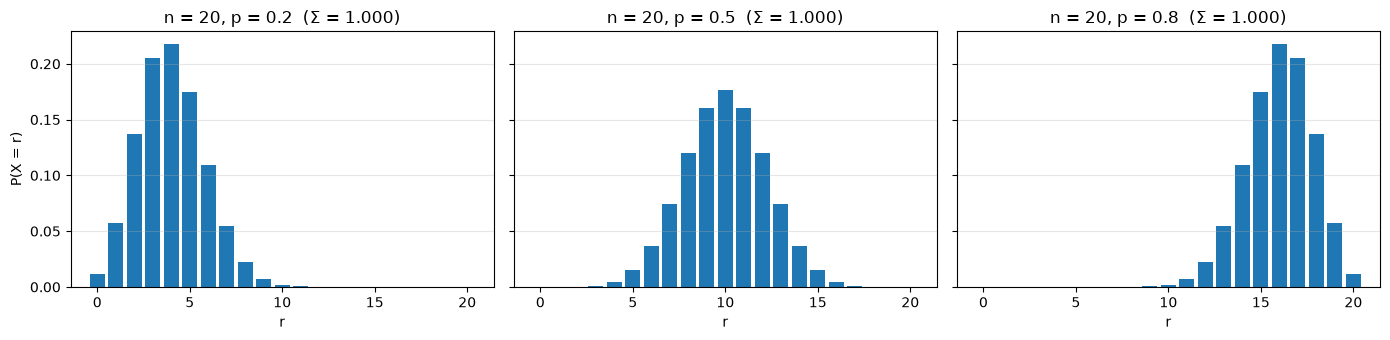

In [13]:
print("P(3 heads in 5 tosses) =", sp.binomial(5, 3) * sp.Rational(1, 2)**5)
N = 20
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, p in zip(axes, (0.2, 0.5, 0.8)):
    probs = [comb(N, k) * p**k * (1 - p)**(N - k) for k in range(N + 1)]
    ax.bar(range(N + 1), probs); ax.set_title(f"n = {N}, p = {p}  (Σ = {sum(probs):.3f})"); ax.set_xlabel("r")
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("P(X = r)")
plt.tight_layout(); plt.show()

## 14. Common Mistakes

| Mistake | Correct |
|---------|---------|
| $k$-th term uses $r = k$ | $k$-th term is $T_k$, which uses $r = k - 1$ |
| $(a + b)^n = a^n + b^n$ | All $n + 1$ terms are needed |
| Forgetting the sign of $b$ in $(a - b)^n$ | Treat $b$ as $-b$: signs alternate, $(-b)^r$ |
| Forgetting to raise the coefficient: $(2x)^3 = 2x^3$ | $(2x)^3 = 8x^3$ |
| Accepting a non-integer $r$ | No term exists unless $0 \le r \le n$ is an integer |
| Confusing "greatest coefficient" with "greatest term" | Greatest *term* depends on the value of $x$ |
| "Coefficient" vs "binomial coefficient" | In $(2x + 3)^5$ the coefficient of $x^2$ is $\binom{5}{2}2^2 3^3$, the binomial coefficient is just $\binom{5}{2}$ |
| Using the any-index expansion when $\lvert x\rvert \ge 1$ | It is only valid for $\lvert x\rvert < 1$ |
| Expanding $(2 + x)^{-1}$ as $2^{-1} - x + \dots$ | First factor out: $\tfrac{1}{2}\left(1 + \tfrac{x}{2}\right)^{-1}$ |
| Number of terms in $(a + b)^n$ is $n$ | It is $n + 1$ |

## 15. Formula Sheet

| Item | Formula |
|------|---------|
| Combination | $\binom{n}{r} = \dfrac{n!}{r!(n - r)!}$ |
| Symmetry | $\binom{n}{r} = \binom{n}{n - r}$ |
| Pascal's rule | $\binom{n}{r} + \binom{n}{r - 1} = \binom{n + 1}{r}$ |
| Binomial theorem | $(a + b)^n = \sum_{r=0}^{n}\binom{n}{r}a^{n-r}b^r$ |
| General term | $T_{r+1} = \binom{n}{r}a^{n-r}b^r$ |
| Number of terms | $n + 1$ |
| Middle term ($n$ even) | $T_{n/2 + 1}$ |
| Middle terms ($n$ odd) | $T_{(n+1)/2}$, $T_{(n+3)/2}$ |
| Greatest term of $(1 + x)^n$ | $m = \dfrac{(n + 1)\lvert x\rvert}{1 + \lvert x\rvert}$; $T_{\lfloor m\rfloor + 1}$ (or $T_m = T_{m+1}$ if $m$ is an integer) |
| Sum of coefficients | $\sum\binom{n}{r} = 2^n$ (put $x = 1$) |
| Alternating sum | $\sum(-1)^r\binom{n}{r} = 0$ |
| Even / odd positions | $2^{n-1}$ each |
| $\sum r\binom{n}{r}$ | $n\,2^{n-1}$ |
| $\sum\binom{n}{r}^2$ | $\binom{2n}{n}$ |
| Any index ($\lvert x\rvert < 1$) | $(1 + x)^n = 1 + nx + \dfrac{n(n - 1)}{2!}x^2 + \dots$ |
| $(1 - x)^{-1}$, $(1 - x)^{-2}$ | $\sum x^r$, $\;\sum (r + 1)x^r$ |
| $(1 - x)^{-n}$ | $\sum\binom{n + r - 1}{r}x^r$ |
| Multinomial coefficient | $\dfrac{n!}{p!\,q!\,s!}$; number of terms in $(a + b + c)^n$ is $\binom{n + 2}{2}$ |

## 16. Practice Problems (with Answers)

### Level 1 — Basics
1. Expand $(x + 2)^5$.
2. Expand $(1 - 2x)^4$.
3. Evaluate $\binom{8}{3}$ and $\binom{10}{7}$.
4. How many terms are in the expansion of $(x + y)^{12}$?
5. Find the 5th term of $\left(2x - \dfrac{1}{x}\right)^8$.
6. Find the coefficient of $x^4$ in $(1 + x)^{10}$.
7. Find the middle term of $(2x + y)^6$.

### Level 2 — Standard
8. Find the coefficient of $x^5$ in $(x + 3)^8$.
9. Find the term independent of $x$ in $\left(x^2 + \dfrac{1}{x}\right)^9$.
10. Find the term independent of $x$ in $\left(x - \dfrac{1}{x}\right)^{10}$.
11. Find $\binom{10}{0} + \binom{10}{1} + \dots + \binom{10}{10}$.
12. Find $\binom{10}{0} + \binom{10}{2} + \binom{10}{4} + \dots + \binom{10}{10}$.
13. Approximate $(0.99)^5$ to 4 decimal places.
14. Expand $(1 + x)^{-1/2}$ up to the $x^3$ term.

### Level 3 — Challenge
15. The coefficients of the 5th, 6th and 7th terms of $(1 + x)^n$ are in AP. Find $n$.
16. Find the remainder when $5^{99}$ is divided by 13.
17. Prove that $9^n - 8n - 1$ is divisible by 64 for every positive integer $n$.
18. Which is larger: $101^{50}$ or $99^{50} + 100^{50}$?
19. Approximate $\sqrt{99}$ using the binomial theorem.
20. Find the coefficient of $a^2b^3c$ in $(a + b + c)^6$ and the number of terms in the expansion.

<details>
<summary><strong>Answers</strong> (click to expand)</summary>

1. $x^5 + 10x^4 + 40x^3 + 80x^2 + 80x + 32$
2. $1 - 8x + 24x^2 - 32x^3 + 16x^4$
3. $56$ and $120$
4. $13$
5. $T_5 = \binom{8}{4}(2x)^4\left(-\tfrac{1}{x}\right)^4 = 1120$
6. $\binom{10}{4} = 210$
7. $T_4 = \binom{6}{3}(2x)^3y^3 = 160x^3y^3$
8. $\binom{8}{3} \cdot 3^3 = 1512$
9. $r = 6$: $\binom{9}{6} = 84$
10. $T_{r+1} = (-1)^r\binom{10}{r}x^{10 - 2r}$, $r = 5$: $-252$
11. $2^{10} = 1024$
12. $2^9 = 512$
13. $1 - 0.05 + 0.001 - 0.00001 \approx 0.9510$
14. $1 - \tfrac{1}{2}x + \tfrac{3}{8}x^2 - \tfrac{5}{16}x^3$
15. $2\binom{n}{5} = \binom{n}{4} + \binom{n}{6} \Rightarrow n^2 - 21n + 98 = 0 \Rightarrow n = 7$ or $14$
16. $5^{99} = 5 \cdot 25^{49} = 5(26 - 1)^{49} \equiv -5 \equiv 8 \pmod{13}$ → remainder $8$
17. $9^n = (1 + 8)^n = 1 + 8n + 64\left[\binom{n}{2} + 8\binom{n}{3} + \dots\right]$
18. $101^{50}$ (see Section 10)
19. $10(1 - 0.01)^{1/2} \approx 10(1 - 0.005 - 0.0000125) = 9.9499$
20. $\dfrac{6!}{2!\,3!\,1!} = 60$; number of terms $\binom{8}{2} = 28$

</details>

In [14]:
# Check the practice answers
print(" 1.", sp.expand((x + 2)**5))
print(" 2.", sp.expand((1 - 2*x)**4))
print(" 3.", comb(8, 3), comb(10, 7))
print(" 4.", len(sp.expand((x + y)**12).args))
print(" 5.", sp.simplify(general_term(2*x, -1/x, 8, 4)))
print(" 6.", sp.expand((1 + x)**10).coeff(x, 4))
print(" 7.", general_term(2*x, y, 6, 3))
print(" 8.", sp.expand((x + 3)**8).coeff(x, 5))
print(" 9.", sp.expand((x**2 + 1/x)**9).as_independent(x)[0])
print("10.", sp.expand((x - 1/x)**10).as_independent(x)[0])
print("11.", sum(comb(10, k) for k in range(11)))
print("12.", sum(comb(10, k) for k in range(0, 11, 2)))
print("13.", round(0.99**5, 4))
print("14.", sp.series((1 + x)**sp.Rational(-1, 2), x, 0, 4))
m = sp.symbols("m", integer=True, positive=True)
eq = sp.expand_func(sp.simplify((2*sp.binomial(m, 5) - sp.binomial(m, 4) - sp.binomial(m, 6)) / sp.binomial(m, 4)))
print("15.", sp.solve(sp.simplify(eq), m), " check:", [(2*comb(k, 5) == comb(k, 4) + comb(k, 6)) for k in (7, 14)])
print("16.", pow(5, 99, 13))
print("17.", all((9**k - 8*k - 1) % 64 == 0 for k in range(1, 51)), "(checked n = 1..50)")
print("18.", "101^50" if 101**50 > 99**50 + 100**50 else "99^50 + 100^50")
print("19.", round(10*(1 - 0.005 - 0.0000125), 4), " actual", round(math.sqrt(99), 4))
E = sp.expand((a + b + c)**6)
print("20.", E.coeff(a, 2).coeff(b, 3).coeff(c, 1), len(E.args))

 1. x**5 + 10*x**4 + 40*x**3 + 80*x**2 + 80*x + 32
 2. 16*x**4 - 32*x**3 + 24*x**2 - 8*x + 1
 3. 56 120
 4. 13
 5. 1120
 6. 210
 7. 160*x**3*y**3
 8. 1512
 9. 84
10. -252
11. 1024
12. 512
13. 0.951
14. 1 - x/2 + 3*x**2/8 - 5*x**3/16 + O(x**4)
15. [7, 14]  check: [True, True]
16. 8
17. True (checked n = 1..50)
18. 101^50
19. 9.9499  actual 9.9499
20. 60 28
